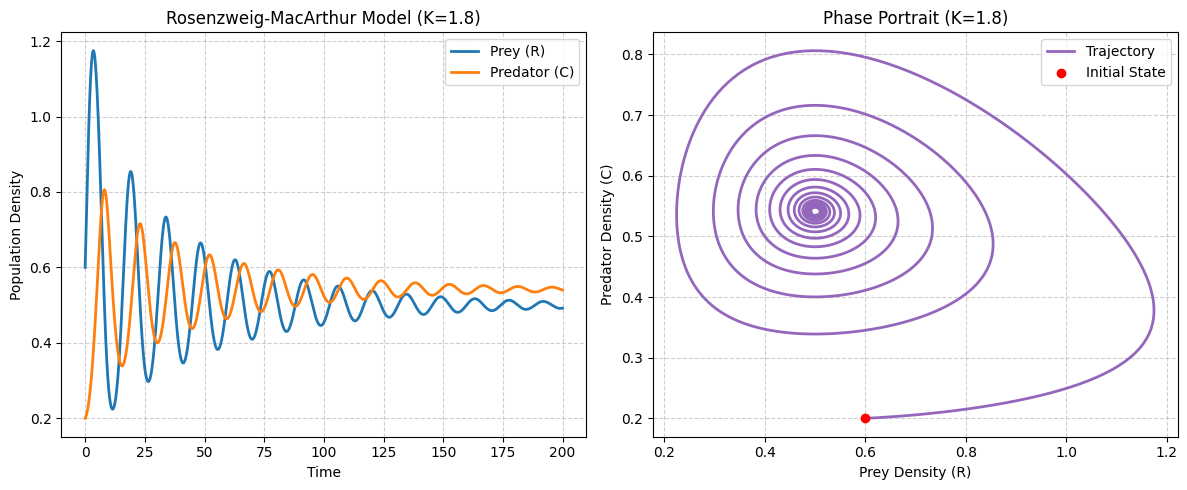

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

t = np.linspace(0, 200, 2000)
initial_state = [0.6, 0.2]
r = 1.0      # Intrinsic growth rate of prey
a = 2.0      # Attack rate
h = 0.5      # Handling time
e = 0.6      # Conversion efficiency
m = 0.4      # Predator per capita mortality rate

k_1 = 1.8 #carrying capacity VARY THIS !!! HEHE

def rosencarthur(y, t, r, a, h, e, m, k):
    R, C = y

    dRdt = r * R * (1 - R/k) - (a * R * C) / (1 + a * R * h)
    dCdt = (e * a * R * C) / (1 + a * R * h) - m * C

    return [dRdt, dCdt]

sol_1 = odeint(rosencarthur, initial_state, t, args=(r, a, h, e, m, k_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Time Series Graph
axes[0].plot(t, sol_1[:, 0], label='Prey (R)', color='tab:blue', linewidth=2)
axes[0].plot(t, sol_1[:, 1], label='Predator (C)', color='tab:orange', linewidth=2)
axes[0].set_title(f"Rosenzweig-MacArthur Model (K={k_1})")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Population Density")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Phase Portrait Graph
axes[1].plot(sol_1[:, 0], sol_1[:, 1], label='Trajectory', color='tab:purple', linewidth=2)
axes[1].scatter(initial_state[0], initial_state[1], color='red', zorder=5, label='Initial State')
axes[1].set_title(f"Phase Portrait (K={k_1})")
axes[1].set_xlabel("Prey Density (R)")
axes[1].set_ylabel("Predator Density (C)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [8]:
# m < e / h
#this part is to check for k_min and k_crit
m_hu = e/h
k_min = m / (a * (e - h * m))
k_crit = (e+h*m)/(a*h*(e-h*m))

print(m_hu)
print(k_min)
print(k_crit)

1.2
0.5000000000000001
2.0000000000000004


In [6]:
#this part is to check equilibrium.

R_star = m / ((e - h * m) * a)
C_star = (e * r * (a * K * (e - h * m) - m)) / (K * ((e - h * m) ** 2) * (a ** 2))

print(R_star, C_star)

0.5000000000000001 0.28125000000000006
